<a href="https://colab.research.google.com/github/debraluna/DebraLuna_DTSC3020_Summer2026/blob/main/ADTA4230_Luna_HW7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 773 stored elements and shape (10, 496)>
  Coords	Values
  (0, 194)	2
  (0, 18)	1
  (0, 102)	1
  (0, 367)	4
  (0, 191)	1
  (0, 32)	6
  (0, 266)	6
  (0, 438)	2
  (0, 51)	5
  (0, 58)	1
  (0, 56)	2
  (0, 464)	1
  (0, 366)	1
  (0, 406)	12
  (0, 411)	3
  (0, 493)	3
  (0, 378)	1
  (0, 448)	2
  (0, 429)	11
  (0, 486)	3
  (0, 20)	10
  (0, 43)	1
  (0, 338)	2
  (0, 155)	8
  (0, 35)	4
  :	:
  (9, 467)	4
  (9, 172)	1
  (9, 117)	1
  (9, 94)	1
  (9, 492)	1
  (9, 275)	1
  (9, 313)	1
  (9, 162)	2
  (9, 165)	1
  (9, 81)	1
  (9, 348)	1
  (9, 421)	1
  (9, 455)	1
  (9, 281)	1
  (9, 134)	1
  (9, 319)	1
  (9, 163)	1
  (9, 381)	1
  (9, 138)	1
  (9, 240)	1
  (9, 435)	1
  (9, 444)	1
  (9, 235)	1
  (9, 95)	1
  (9, 390)	1
tent       52
pole       11
well        9
rain        9
great       8
           ..
real        1
reduc       1
reduct      1
regret      1
product     1
Length: 376, dtype: int64
tent        52
pole        11
well         9
rain      

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/tmp/ipykernel_4353/628000768.py:151: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(column_sums[sorted_indices])
/tmp/ipykernel_4353/628000768.py:153: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(column_sums[sorted_indices][:20])


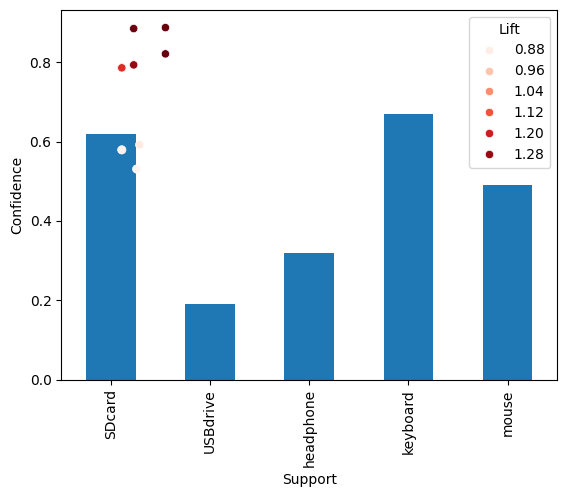

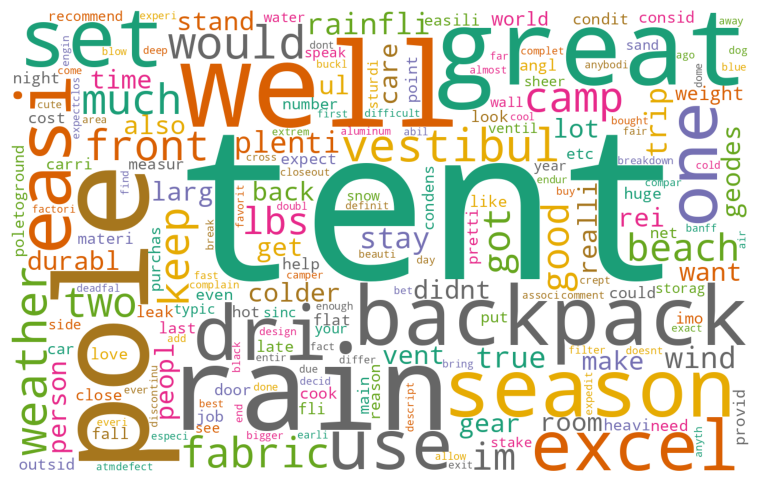

<Figure size 640x480 with 0 Axes>

In [83]:
# DDL2194
# Ex:14.5 this code cell imports the pandas and loads transaction dataset

import pandas as pd
myData = pd.read_csv('Transaction-1.csv', header = None)
myData.head()

# DDL2194
# this code cell imports and loads the transaction dataset into a DataFrame

Transactions = [transaction[~pd.isnull(transaction)] for transaction in myData.
                values]
Transactions[0:5]

# DDL2194
# install Mlxtend
%pip install mlxtend

# DDL2194
# transaction encoder
from mlxtend.preprocessing import TransactionEncoder

encoder = TransactionEncoder()
Transactions_Encoded = encoder.fit_transform(Transactions)
Transactions_df = pd.DataFrame(Transactions_Encoded, columns = encoder.columns_)
Transactions_df.head()

# DDL2194
# This code cell calculates the support for each item
Transactions_df.sum() / len(Transactions_df)

# DDL2194
# this code cell creates a bar chart showing item support
(Transactions_df.sum() / len(Transactions_df)).plot.bar();

# DDL2194
# this code cell installs the efficient-apriori package
%pip install efficient-apriori

# DDL2194
# this code cell imports the apriori function
from efficient_apriori import apriori
itemsets, rules = apriori(Transactions, min_support =  0.1, min_confidence = 0.5)

# DDL2194
# code cell stores the association rules into a pandas DataFrame
Rules = pd.DataFrame({'Rule': [rule.__repr__() for rule in rules],
                      'Confidence': [rule.confidence for rule in rules],'Support': [rule.support for rule in rules],
                      'Lift': [rule.lift for rule in rules],
                      'Count': [rule.count_full for rule in rules]})

Rules.sort_values('Lift', ascending = False)

# DDL2194
# this code cell creates a scatter plot for support, confidence, and lift
import seaborn as sns

sns.scatterplot(x = 'Support',
                y = 'Confidence',
                hue = 'Lift',
                data = Rules,
                palette = 'Reds');

# DDL2194
# Ex: 14.6 import pandas and load the Reviews dataset
import pandas as pd
myData = pd.read_csv('Reviews-1.csv', encoding='latin-1')
myData.head()

# DDL2194
# this code cell creates a document-term matrix from the review text
from sklearn.feature_extraction.text import CountVectorizer
Vectorizer = CountVectorizer()
dtm_Corpus = Vectorizer.fit_transform(myData['text'])
print(dtm_Corpus)

# DDL2194
# this code cell converts the doc-term matric into a DataFrame
dtm_Corpus = pd.DataFrame(dtm_Corpus.toarray(), columns=Vectorizer.get_feature_names_out())
dtm_Corpus

# DDL2194
# this code cell creates a doc-term matrix fro mthe review text
import re
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

import nltk

nltk.download('stopwords')

# DDL2194
# this code cell returns the processed, reduced, and stemmed words, joined
# back together into a single string
def preprocess_text(text, custom_stopwords):
  # convert to lowercase
  text = text.lower()

  # remove punctuation
  text = re.sub(r'[^\w\s]', '', text)

  # remove numbers
  text = re.sub(r'\d+', '', text)

  # remove stop words
  stop_words = set(stopwords.words('english'))

  # add custom stopwords to the stopword list
  if custom_stopwords is not None:
    stop_words.update(custom_stopwords)

  words = text.split()
  words = [word for word in words if word not in stop_words]

  # word stemming using the snowball stemmer
  stemmer = SnowballStemmer('english')
  words = [stemmer.stem(word) for word in words]

  # return the preprocessed words, joined back together into a single string
  return ' '.join(words)

# add custom stop words
my_stopwords = {'text'}
myData['text_reduced'] = myData['text'].apply(preprocess_text, custom_stopwords = my_stopwords)

# DDL2194
# this code cell displays the updated DataFrame
myData.head()

# DDL2194
# this code cell creates DTM using reduced corpus
from sklearn.feature_extraction.text import CountVectorizer

Vectorizer = CountVectorizer()

dtm_Corpus_Reduced = Vectorizer.fit_transform(myData['text_reduced'])

dtm_Corpus_Reduced = pd.DataFrame(dtm_Corpus_Reduced.toarray(),
                                  columns=Vectorizer.get_feature_names_out())

dtm_Corpus_Reduced

# DDL2194
# compute the sum of each column and save the sums in an array named column_sums
column_sums = dtm_Corpus_Reduced.sum()

import numpy as np
sorted_indices = np.argsort(column_sums)[::-1]

# Finally, we print the sorted column sums. Enter:
print(column_sums[sorted_indices])

print(column_sums[sorted_indices][:20])

# DDL2194
# Ex: 14.7 install the WordCloud package
%pip install wordcloud

# DDL2194
# import the libraries for creating a wordcloud
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# DDL2194
# create variable from WordCloud
word_cloud = WordCloud(width=1280, height=800, background_color='white', colormap='Dark2').generate_from_frequencies(dtm_Corpus_Reduced.sum())

# DDL2194
# display word cloud
plt.figure(figsize=(10,6))
plt.imshow(word_cloud)
plt.axis('off')
plt.show()

# DDL2194
# this code cell saves the word cloud image as a png file
plt.savefig("Wordcloud_tent.png")